In [1]:
# ============================================================
# ANÁLISE ESPACIAL DOS INDICADORES
# ============================================================
# Projeto: Monitoramento de Vegetação — Validação PRA
# Autora: Bruna Bertini
# Data: 2026
#
# Objetivo: Analisar a distribuição espacial dos índices
#          dentro da propriedade.
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

# Configurações do matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Caminhos do projeto
BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"
RESULTS_DIR = BASE / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Cores padrão dos índices
CORES = {"NDVI": "#2ca02c", "EVI": "#1f77b4", "NDMI": "#ff7f0e"}

print(f"BASE:        {BASE}")
print(f"ÍNDICES:     {IND_DIR}")
print(f"RESULTADOS:  {RESULTS_DIR}")
print(f"\n✓ Ambiente configurado")

BASE:        C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao
ÍNDICES:     C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices
RESULTADOS:  C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results

✓ Ambiente configurado


In [2]:
# ============================================================
# 1-  CARREGAR OS TRÊS ÍNDICES (MEDIANA 2025)
# ============================================================

# Carregar os três rasters
ndvi = rioxarray.open_rasterio(IND_DIR / "ndvi" / "ndvi_mediana_2025.tif").squeeze()
evi  = rioxarray.open_rasterio(IND_DIR / "evi"  / "evi_mediana_2025.tif").squeeze()
ndmi = rioxarray.open_rasterio(IND_DIR / "ndmi" / "ndmi_mediana_2025.tif").squeeze()

print("=" * 80)
print("RESOLUÇÃO DOS ÍNDICES")
print("=" * 80)
print(f"\nNDVI: shape={ndvi.shape}, resolução={ndvi.rio.resolution()[0]:.1f} m, CRS={ndvi.rio.crs}")
print(f"EVI:  shape={evi.shape},  resolução={evi.rio.resolution()[0]:.1f} m, CRS={evi.rio.crs}")
print(f"NDMI: shape={ndmi.shape}, resolução={ndmi.rio.resolution()[0]:.1f} m, CRS={ndmi.rio.crs}")

# Verificar se as grades são iguais
if ndvi.shape == evi.shape == ndmi.shape:
    print("\n✅ Todos os índices têm a MESMA grade (mesmo shape e CRS)")
    evi_aligned = evi
    ndmi_aligned = ndmi
else:
    print("\n⚠️ Grades diferentes — realinhando EVI e NDMI à grade do NDVI...")
    evi_aligned = evi.rio.reproject_match(ndvi)
    ndmi_aligned = ndmi.rio.reproject_match(ndvi)
    print(f"   NDVI: {ndvi.shape}")
    print(f"   EVI:  {evi_aligned.shape}")
    print(f"   NDMI: {ndmi_aligned.shape}")

RESOLUÇÃO DOS ÍNDICES

NDVI: shape=(222, 140), resolução=10.0 m, CRS=EPSG:32722
EVI:  shape=(222, 140),  resolução=10.0 m, CRS=EPSG:32722
NDMI: shape=(112, 71), resolução=20.0 m, CRS=EPSG:32722

⚠️ Grades diferentes — realinhando EVI e NDMI à grade do NDVI...
   NDVI: (222, 140)
   EVI:  (222, 140)
   NDMI: (222, 140)


In [3]:
# ============================================================
# 2- ESTATÍSTICAS COMPARATIVAS DOS TRÊS ÍNDICES
# ============================================================

def calcular_stats(arr, nome):
    """Calcula estatísticas descritivas de um raster."""
    vals = arr.values[~np.isnan(arr.values)]
    return {
        "Índice": nome,
        "N válidos": len(vals),
        "N NaN": arr.size - len(vals),
        "Mín": vals.min(),
        "P25": np.percentile(vals, 25),
        "Mediana": np.median(vals),
        "Média": vals.mean(),
        "P75": np.percentile(vals, 75),
        "Máx": vals.max(),
        "Desv Pad": vals.std()
    }

df_stats = pd.DataFrame([
    calcular_stats(ndvi, "NDVI"),
    calcular_stats(evi_aligned, "EVI"),
    calcular_stats(ndmi_aligned, "NDMI")
])

print("=" * 100)
print("ESTATÍSTICAS COMPARATIVAS — MEDIANA 2025")
print("=" * 100)
print(df_stats.to_string(index=False, float_format="%.3f"))

output = RESULTS_DIR / "estatisticas_espaciais.csv"
df_stats.to_csv(output, index=False)
print(f"\n✅ Salvo: {output}")

ESTATÍSTICAS COMPARATIVAS — MEDIANA 2025
Índice  N válidos  N NaN    Mín    P25  Mediana  Média   P75   Máx  Desv Pad
  NDVI      19358  11722  0.130  0.375    0.489  0.542 0.749 0.899     0.203
   EVI      31080      0  0.000  0.000    0.219  0.201 0.337 0.682     0.184
  NDMI      19780  11300 -0.280 -0.138   -0.025  0.020 0.181 0.465     0.190

✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\estatisticas_espaciais.csv


In [4]:
# ============================================================
# 3- CORRELAÇÃO ESPACIAL ENTRE OS ÍNDICES
# ============================================================

# Máscara de pixels válidos em TODOS os índices
mask = (~np.isnan(ndvi.values) & 
        ~np.isnan(evi_aligned.values) & 
        ~np.isnan(ndmi_aligned.values))

print(f"Pixels válidos em todos os índices: {mask.sum():,}")
print(f"Total de pixels: {mask.size:,}")
print(f"Cobertura: {mask.sum()/mask.size*100:.1f}%\n")

# Extrair valores
ndvi_flat = ndvi.values[mask]
evi_flat = evi_aligned.values[mask]
ndmi_flat = ndmi_aligned.values[mask]

# Calcular correlação
corr_matrix = np.corrcoef([ndvi_flat, evi_flat, ndmi_flat])

corr_df = pd.DataFrame(
    corr_matrix,
    index=["NDVI", "EVI", "NDMI"],
    columns=["NDVI", "EVI", "NDMI"]
)

print("=" * 80)
print("MATRIZ DE CORRELAÇÃO ESPACIAL (pixel a pixel)")
print("=" * 80)
print(corr_df.to_string(float_format="%.3f"))

# Interpretação automática
print("\n" + "=" * 80)
print("INTERPRETAÇÃO")
print("=" * 80)

ndvi_evi = corr_df.loc["NDVI", "EVI"]
ndvi_ndmi = corr_df.loc["NDVI", "NDMI"]
evi_ndmi = corr_df.loc["EVI", "NDMI"]

def classificar_corr(valor):
    if valor > 0.85:
        return "✅ Altíssima"
    elif valor > 0.7:
        return "✅ Alta"
    elif valor > 0.5:
        return "⚠️ Moderada"
    elif valor > 0.3:
        return "⚠️ Baixa"
    else:
        return "❌ Muito baixa"

print(f"\nNDVI × EVI:  {ndvi_evi:.3f} — {classificar_corr(ndvi_evi)}")
print(f"NDVI × NDMI: {ndvi_ndmi:.3f} — {classificar_corr(ndvi_ndmi)}")
print(f"EVI  × NDMI: {evi_ndmi:.3f} — {classificar_corr(evi_ndmi)}")

output = RESULTS_DIR / "correlacao_indices.csv"
corr_df.to_csv(output)
print(f"\n✅ Salvo: {output}")

Pixels válidos em todos os índices: 19,336
Total de pixels: 31,080
Cobertura: 62.2%

MATRIZ DE CORRELAÇÃO ESPACIAL (pixel a pixel)
      NDVI   EVI  NDMI
NDVI 1.000 0.931 0.954
EVI  0.931 1.000 0.901
NDMI 0.954 0.901 1.000

INTERPRETAÇÃO

NDVI × EVI:  0.931 — ✅ Altíssima
NDVI × NDMI: 0.954 — ✅ Altíssima
EVI  × NDMI: 0.901 — ✅ Altíssima

✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\correlacao_indices.csv


✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\histogramas_comparativos.png


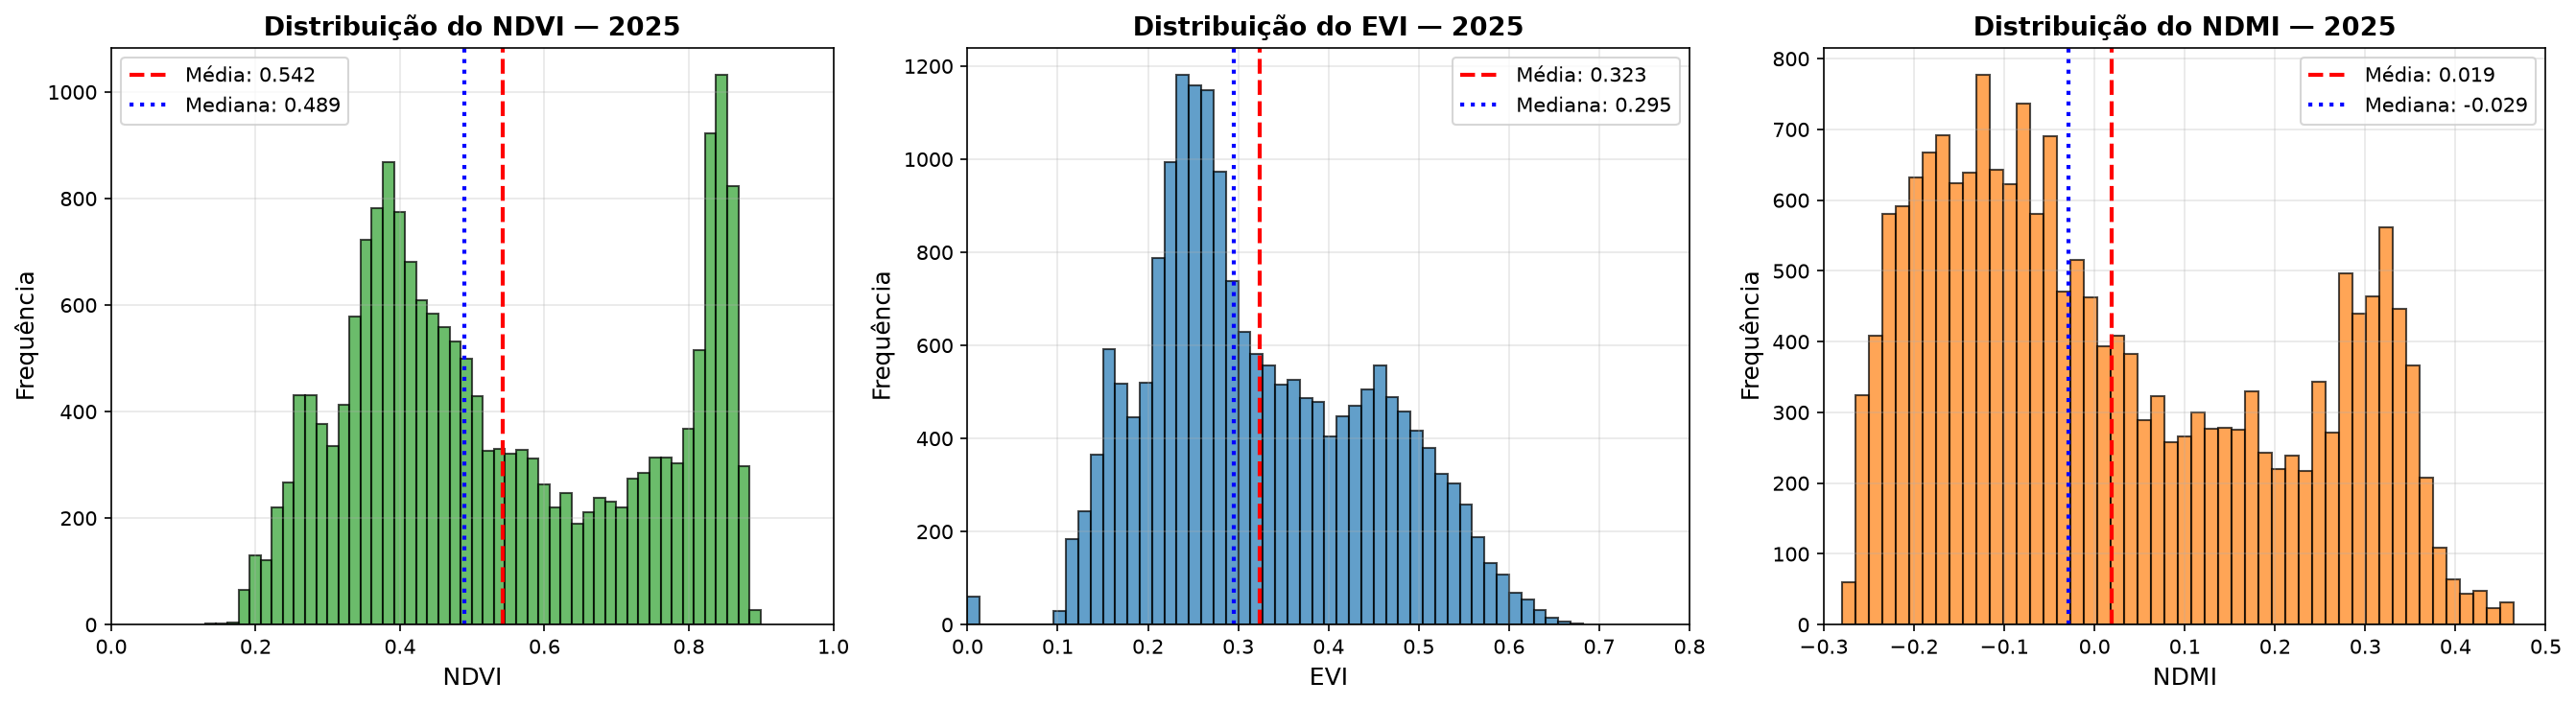

In [5]:
# ============================================================
# 4 - HISTOGRAMAS COMPARATIVOS DOS TRÊS ÍNDICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

dados = [
    (axes[0], ndvi_flat, "NDVI", CORES["NDVI"], (0, 1)),
    (axes[1], evi_flat, "EVI", CORES["EVI"], (0, 0.8)),
    (axes[2], ndmi_flat, "NDMI", CORES["NDMI"], (-0.3, 0.5))
]

for ax, vals, nome, cor, (vmin, vmax) in dados:
    ax.hist(vals, bins=50, color=cor, alpha=0.7, edgecolor="black")
    ax.axvline(vals.mean(), color="red", linestyle="--",
               linewidth=2, label=f"Média: {vals.mean():.3f}")
    ax.axvline(np.median(vals), color="blue", linestyle=":",
               linewidth=2, label=f"Mediana: {np.median(vals):.3f}")
    ax.set_xlabel(nome, fontsize=12)
    ax.set_ylabel("Frequência", fontsize=12)
    ax.set_title(f"Distribuição do {nome} — 2025", fontsize=13, fontweight="bold")
    ax.set_xlim(vmin, vmax)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

output = RESULTS_DIR / "histogramas_comparativos.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()

✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\matriz_correlacao.png


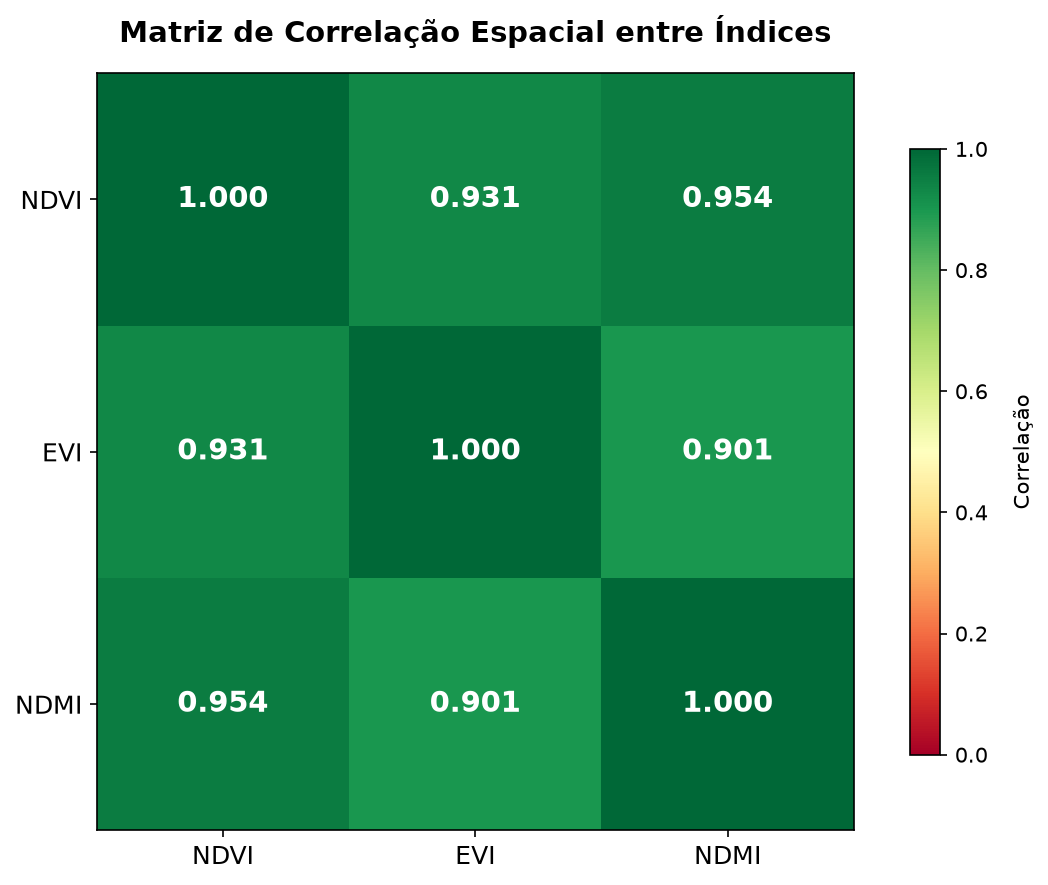

In [6]:
# ============================================================
# 5- MATRIZ DE CORRELAÇÃO — HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=0, vmax=1)

# Adicionar valores nas células
for i in range(3):
    for j in range(3):
        texto = f"{corr_matrix[i, j]:.3f}"
        cor_texto = "white" if corr_matrix[i, j] > 0.7 else "black"
        ax.text(j, i, texto, ha="center", va="center",
                color=cor_texto, fontsize=14, fontweight="bold")

# Rótulos
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["NDVI", "EVI", "NDMI"], fontsize=12)
ax.set_yticklabels(["NDVI", "EVI", "NDMI"], fontsize=12)

ax.set_title("Matriz de Correlação Espacial entre Índices",
             fontsize=14, fontweight="bold", pad=15)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Correlação", rotation=90, labelpad=12)

plt.tight_layout()

output = RESULTS_DIR / "matriz_correlacao.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()

In [7]:
# ============================================================
# 6 - RESUMO FINAL 
# ============================================================

print("=" * 80)
print("RESUMO FINAL")
print("=" * 80)

print(f"\n✓ Produtos gerados em: {RESULTS_DIR}")

print(f"\n📄 Arquivos CSV:")
for f in sorted(RESULTS_DIR.glob("*.csv")):
    tamanho = f.stat().st_size / 1024
    print(f"   - {f.name} ({tamanho:.1f} KB)")

print(f"\n🖼️ Arquivos PNG:")
for f in sorted(RESULTS_DIR.glob("*.png")):
    tamanho = f.stat().st_size / 1024
    print(f"   - {f.name} ({tamanho:.1f} KB)")

print(f"\n📊 Síntese:")
print(f"   NDVI média: {ndvi_flat.mean():.3f}")
print(f"   EVI  média: {evi_flat.mean():.3f}")
print(f"   NDMI média: {ndmi_flat.mean():.3f}")
print(f"   Correlação NDVI×EVI:  {ndvi_evi:.3f}")
print(f"   Correlação NDVI×NDMI: {ndvi_ndmi:.3f}")

print(f"\n✓ Etapa 7 concluída")
print(f"✓ Próximo: Etapa 8 — Mapas de Anomalias")

RESUMO FINAL

✓ Produtos gerados em: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results

📄 Arquivos CSV:
   - 06_anomalias_intraanuais.csv (44.6 KB)
   - 06_sazonalidade.csv (2.3 KB)
   - 06_serie_anual_completa.csv (1.7 KB)
   - 06_serie_intraanual_completa.csv (30.9 KB)
   - 07_correlacao_indices.csv (0.2 KB)
   - 07_estatisticas_espaciais.csv (0.3 KB)
   - 08_anomalias_interanuais.csv (0.3 KB)
   - correlacao_indices.csv (0.2 KB)
   - estatisticas_espaciais.csv (0.3 KB)

🖼️ Arquivos PNG:
   - 06_anomalias_intraanuais.png (539.8 KB)
   - 06_sazonalidade.png (537.0 KB)
   - 06_serie_intraanual_completa.png (1249.6 KB)
   - 07_histogramas_comparativos.png (220.7 KB)
   - 07_mapas_comparativos.png (697.1 KB)
   - 07_matriz_correlacao.png (101.1 KB)
   - 08_mapa_anomalias.png (440.7 KB)
   - histogramas_comparativos.png (220.7 KB)
   - mapa_caracterizacao_ambiental.png (878.3 KB)
   - matriz_correlacao.png (101.1 KB)

📊 Síntese:
   NDVI média: 0.542
   EVI  média: 0.3